In [26]:
import pandas as pd
import numpy as np

In [27]:
df = pd.read_csv('data/data.csv', encoding='latin1')

## EDA

In [28]:
df.shape

(541909, 8)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [31]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

In [32]:
missing = df.isnull().sum()
percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Value' : missing,
    'Percentage (%)':percent.round(2)
})

print(missing_df)

             Missing Value  Percentage (%)
InvoiceNo                0            0.00
StockCode                0            0.00
Description           1454            0.27
Quantity                 0            0.00
InvoiceDate              0            0.00
UnitPrice                0            0.00
CustomerID          135080           24.93
Country                  0            0.00


In [33]:
df.duplicated().sum()

5268

# Explanation

<ul>
    <li>There are 541909 row and 8 column</li>
    <li>Description value had 1454 missing values</li>
    <li>CustomerID had 135080 missing values</li>
    <li>There are 5268 duplicated data </li>
</ul>

In [34]:
df_cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
df_normal = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Normal orders: {df_normal.shape[0]}")
print(f"Cancelled orders: {df_cancelled.shape[0]}")

Normal orders: 532621
Cancelled orders: 9288


In [35]:
print(df_normal.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     134697
Country             0
dtype: int64


In [36]:
df_normal = df_normal.dropna(subset=['Description'])
print(f"Rows after removing missing Description: {df_normal.shape[0]}")

Rows after removing missing Description: 531167


In [37]:
df_all = df_normal.copy()
df_customers = df_normal.dropna(subset=['CustomerID'])

print(f"df_all rows: {df_all.shape[0]}")
print(f"df_customers rows: {df_customers.shape[0]}")

df_all rows: 531167
df_customers rows: 397924


In [38]:
# Remove invalid quantity
df_all = df_all[df_all['Quantity'] > 0]
df_customers = df_customers[df_customers['Quantity'] > 0]

print(f"df_all rows after removing invalid quantity: {df_all.shape[0]}")
print(f"df_customers rows after removing invalid quantity: {df_customers.shape[0]}")


df_all rows after removing invalid quantity: 530693
df_customers rows after removing invalid quantity: 397924


In [39]:
# Remove invalid UnitPrice
df_all = df_all[df_all['UnitPrice'] > 0]
df_customers = df_customers[df_customers['UnitPrice'] > 0]

print(f"df_all rows after removing invalid UnitPrice: {df_all.shape[0]}")
print(f"df_customers rows after removing invalid UnitPrice: {df_customers.shape[0]}")

df_all rows after removing invalid UnitPrice: 530104
df_customers rows after removing invalid UnitPrice: 397884


In [40]:
df_all = df_all.drop_duplicates()
df_customers = df_customers.drop_duplicates()

print(f"df_all rows after removing duplicates: {df_all.shape[0]}")
print(f"df_customers rows after removing duplicates: {df_customers.shape[0]}")

df_all rows after removing duplicates: 524878
df_customers rows after removing duplicates: 392692


In [41]:
# Fix InvoiceDate — convert text to datetime
df_all['InvoiceDate'] = pd.to_datetime(df_all['InvoiceDate'])
df_customers['InvoiceDate'] = pd.to_datetime(df_customers['InvoiceDate'])

# Fix CustomerID — convert decimal to integer
df_customers['CustomerID'] = df_customers['CustomerID'].astype(int)

# Check the result
print(df_all.dtypes)
print(df_customers.dtypes)

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
dtype: object


In [42]:
# Revenue per row = quantity × unit price
df_all['TotalPrice'] = df_all['Quantity'] * df_all['UnitPrice']
df_customers['TotalPrice'] = df_customers['Quantity'] * df_customers['UnitPrice']

print(df_all[['Quantity', 'UnitPrice', 'TotalPrice']].head())

   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [43]:
# Extract from df_all
df_all['Month'] = df_all['InvoiceDate'].dt.month
df_all['Year'] = df_all['InvoiceDate'].dt.year
df_all['YearMonth'] = df_all['InvoiceDate'].dt.to_period('M')

# Extract from df_customers
df_customers['Month'] = df_customers['InvoiceDate'].dt.month
df_customers['Year'] = df_customers['InvoiceDate'].dt.year
df_customers['YearMonth'] = df_customers['InvoiceDate'].dt.to_period('M')

print(df_all[['InvoiceDate', 'Month', 'Year', 'YearMonth']].head())

          InvoiceDate  Month  Year YearMonth
0 2010-12-01 08:26:00     12  2010   2010-12
1 2010-12-01 08:26:00     12  2010   2010-12
2 2010-12-01 08:26:00     12  2010   2010-12
3 2010-12-01 08:26:00     12  2010   2010-12
4 2010-12-01 08:26:00     12  2010   2010-12


In [44]:
total_revenue = df_all['TotalPrice'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £10,642,110.80


In [45]:
total_orders = df_all['InvoiceNo'].nunique()
total_customers = df_customers['CustomerID'].nunique()

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

Total Orders: 19,960
Total Customers: 4,338


In [46]:
revenue_by_country = df_all.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(revenue_by_country)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


Business Insights 🧠
<ul>
    <li> Heavy UK dependency
    The UK alone generates 84.6% of total revenue. That's a risk — if anything disrupts UK sales, the whole business suffers.</li>
    <li> Europe is the next opportunity
    Netherlands, Ireland, Germany and France together make up about 9.5% of revenue. There's clear demand across Europe worth investing in.</li>
    <li> Australia is surprisingly strong
    For a non-European country with higher shipping costs, Australia ranking 6th is interesting — suggests strong demand worth exploring.</li>
</ul>

TOP 10 BEST SELLING PRODUCT

### BY QUANTITY

In [47]:
top_products_qty = df_all.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products_qty)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64


### BY REVENUE

In [48]:
top_products_rev = df_all.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_products_rev)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalPrice, dtype: float64


## Question 4 — Top 10 Best Selling Products

### By Quantity
PAPER CRAFT, LITTLE BIRDIE dominates with 80,995 units sold, 
followed by MEDIUM CERAMIC TOP STORAGE JAR with 78,033 units.

### By Revenue
DOTCOM POSTAGE ranks #1 with £206,248 — however this is a 
**shipping charge, not a real product**. This is a data quality 
issue worth flagging.

### Key Insight
**PAPER CRAFT, LITTLE BIRDIE** is the star product — appearing 
#1 in quantity and #3 in revenue, meaning it sells in huge 
volumes AND generates strong revenue.

### Suspicious Entries
- **DOTCOM POSTAGE** and **POSTAGE** — shipping fees mixed with products
- **Manual** — manually entered transactions, not a real product

In [49]:
monthly_revenue = df_all.groupby('YearMonth')['TotalPrice'].sum()
print(monthly_revenue)

YearMonth
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: TotalPrice, dtype: float64


## Question 5 — Monthly Revenue Trend

Revenue shows a clear seasonal pattern, peaking in **November 2011** 
at £1,503,866 — nearly 3x the weakest month (February at £522,545).

### Key Insights
- **Sep-Nov spike** — Christmas gift buying season drives revenue
- **Jan-Feb slump** — post holiday drop, opportunity for promotions
- **December 2011 is incomplete** — data only goes up to Dec 9, 
  so the low number doesn't reflect the full month

### Recommendation
The business should prepare extra inventory and marketing budget 
from **September onwards** to capitalize on the seasonal demand.

In [ ]:
total_invoices = df_all['InvoiceNo'].nunique()
cancelled_invoices = df_cancelled['InvoiceNo'].nunique()
cancellation_rate = (cancelled_invoices / total_invoices) * 100

print(f"Total Normal Orders: {total_invoices:,}")
print(f"Total Cancelled Orders: {cancelled_invoices:,}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Total Normal Orders: 19,960
Total Cancelled Orders: 3,836
Cancellation Rate: 19.22%


In [51]:
top_cancelled = df_cancelled.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)
print(top_cancelled)

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Manual                                  4066
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
PINK BLUE FELT CRAFT TRINKET BOX        2617
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
Name: Quantity, dtype: int64


## Question 6 — Cancellation Analysis

Overall cancellation rate is **19.22%** — roughly 1 in 5 orders 
gets cancelled, which is worth investigating.

### Suspicious Finding
PAPER CRAFT, LITTLE BIRDIE has identical sold and cancelled 
quantities (80,995). This suggests these may be stock adjustments 
or system corrections rather than real customer cancellations.

### Recommendation
The business should investigate whether cancellations represent:
- Real customer cancellations
- Warehouse stock adjustments  
- System data entry errors

A 19.22% cancellation rate needs urgent attention if these 
are genuine customer cancellations.

In [52]:
import matplotlib.pyplot as plt

# Makes charts appear bigger and cleaner
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

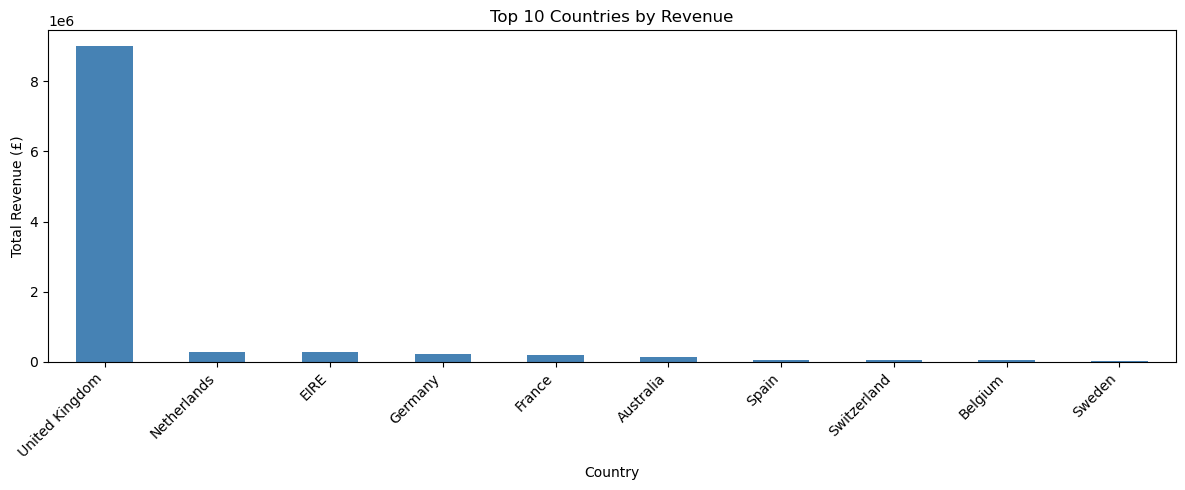

In [53]:
    revenue_by_country = df_all.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
revenue_by_country.plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

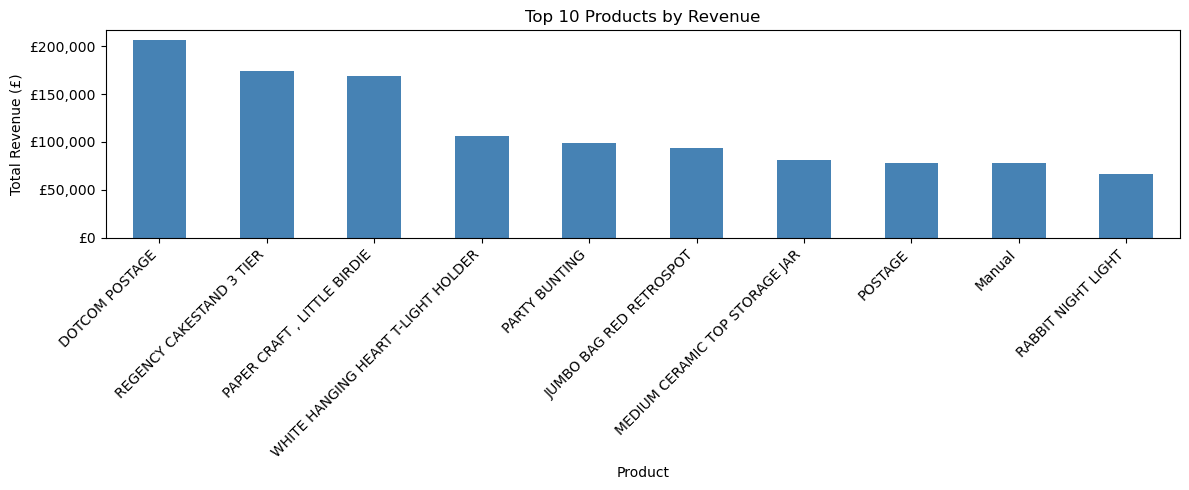

In [54]:
top_products_rev = df_all.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products_rev.plot(kind='bar', color='steelblue')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

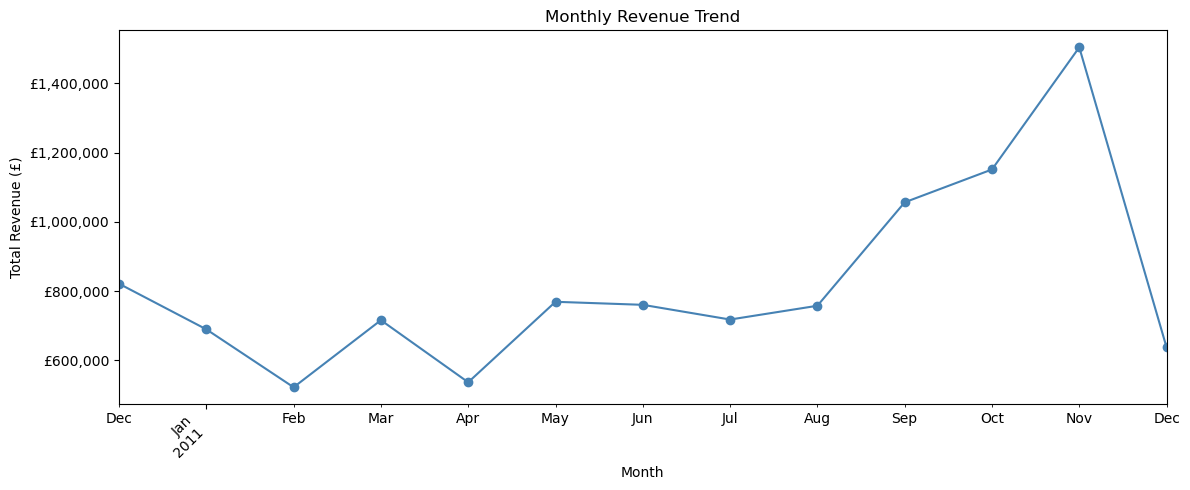

In [55]:
monthly_revenue = df_all.groupby('YearMonth')['TotalPrice'].sum()

plt.figure()
monthly_revenue.plot(kind='line', color='steelblue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


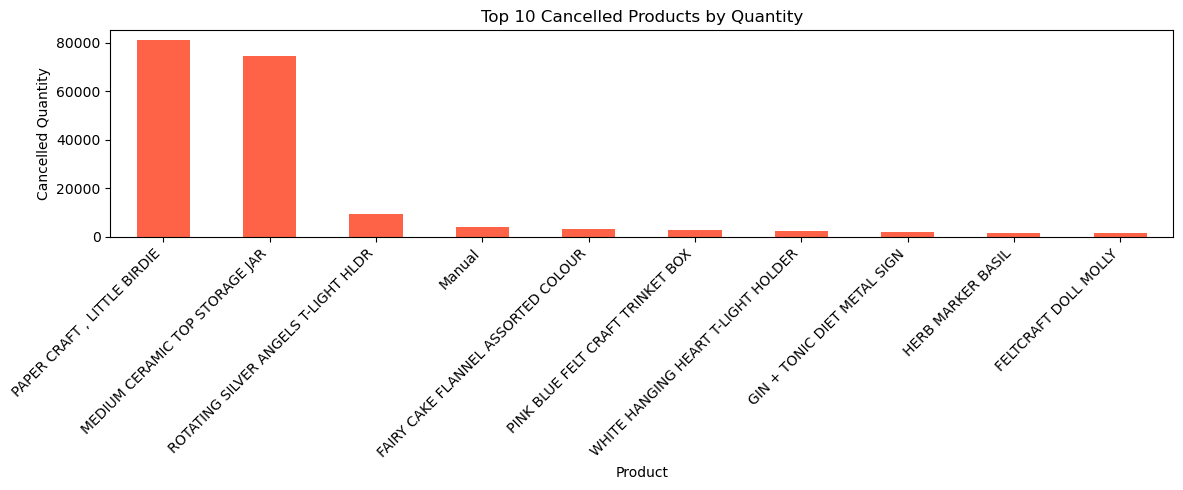

In [56]:
top_cancelled = df_cancelled.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False).head(10)

plt.figure()
top_cancelled.plot(kind='bar', color='tomato')
plt.title('Top 10 Cancelled Products by Quantity')
plt.xlabel('Product')
plt.ylabel('Cancelled Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [57]:
df_all.to_csv('data/cleaned_data.csv', index=False)

In [58]:
df_all.head(10000).to_csv('data/cleaned_data_sample.csv', index=False)